# Showcase — NO₂ over China and the 2020 COVID lockdown (Sentinel-5P)

When China locked down in early 2020, traffic and industry collapsed and the fall in air pollution was visible from orbit. **Sentinel-5P/TROPOMI** maps tropospheric NO₂. This notebook maps Feb–Mar 2019 vs 2020 with pyramids' `Dataset.plot()` and builds a three-year monthly time series.

## What this notebook does

1. **Map** mean NO₂ for Feb–Mar 2019, 2020 and the difference with `Dataset.plot()`.
2. **Build a monthly time series** 2019–2021 (the seasonal cycle, lockdown dip, rebound).

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`.

### Credentials

This notebook reads its credentials from a `.env` file at the repository root
(loaded with `python-dotenv` by the setup cell below; your `PATH` is left
untouched). Create that `.env` with at least:

```text
GEE_SERVICE_ACCOUNT="your-sa@your-project.iam.gserviceaccount.com"
GEE_SERVICE_KEY="/path/to/your/service-account-key.json"
```


In [ ]:
# Credentials — load the repo-root .env, then read the keys (clear KeyError if any is missing).
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))

SERVICE_ACCOUNT = os.environ["GEE_SERVICE_ACCOUNT"]   # Earth Engine service-account email (.env)
SERVICE_KEY = os.environ["GEE_SERVICE_KEY"]           # path to the service-account JSON key (.env)


In [1]:
import os, tempfile, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset   # pyramids' own plotting

warnings.filterwarnings("ignore")
logger.remove()

def plot_arr(arr, like_path, ax, **kw):
    """Colour-map a single-band derived grid (the NO2 column) with pyramids Dataset.plot."""
    src = like_path
    return (Dataset.create_from_array(arr=arr[None, :, :].astype("float32"),
                                      geo=src.geotransform, epsg=src.epsg)
            .plot(band=0, ax=ax, **kw))

from datetime import date
AOI = [108.0, 28.0, 122.5, 41.0]; C = "COPERNICUS/S5P/OFFL/L3_NO2"
NO2 = "tropospheric_NO2_column_number_density"
a2019 = EarthLens(data_source="gee", cadence="raw", dataset=C, variables=[NO2], aoi=AOI, start="2019-02-01", end="2019-03-15", scale=7000, reducer="mean").load()[0]
a2020 = EarthLens(data_source="gee", cadence="raw", dataset=C, variables=[NO2], aoi=AOI, start="2020-02-01", end="2020-03-15", scale=7000, reducer="mean").load()[0]
print("composites:", bool(a2019), bool(a2020))

composites: True True


## Maps: Feb–Mar 2019 vs 2020 — `Dataset.plot()`

The two years are drawn on a shared colour scale; the difference (a derived array) is wrapped back into a Dataset so it too uses `Dataset.plot()`.

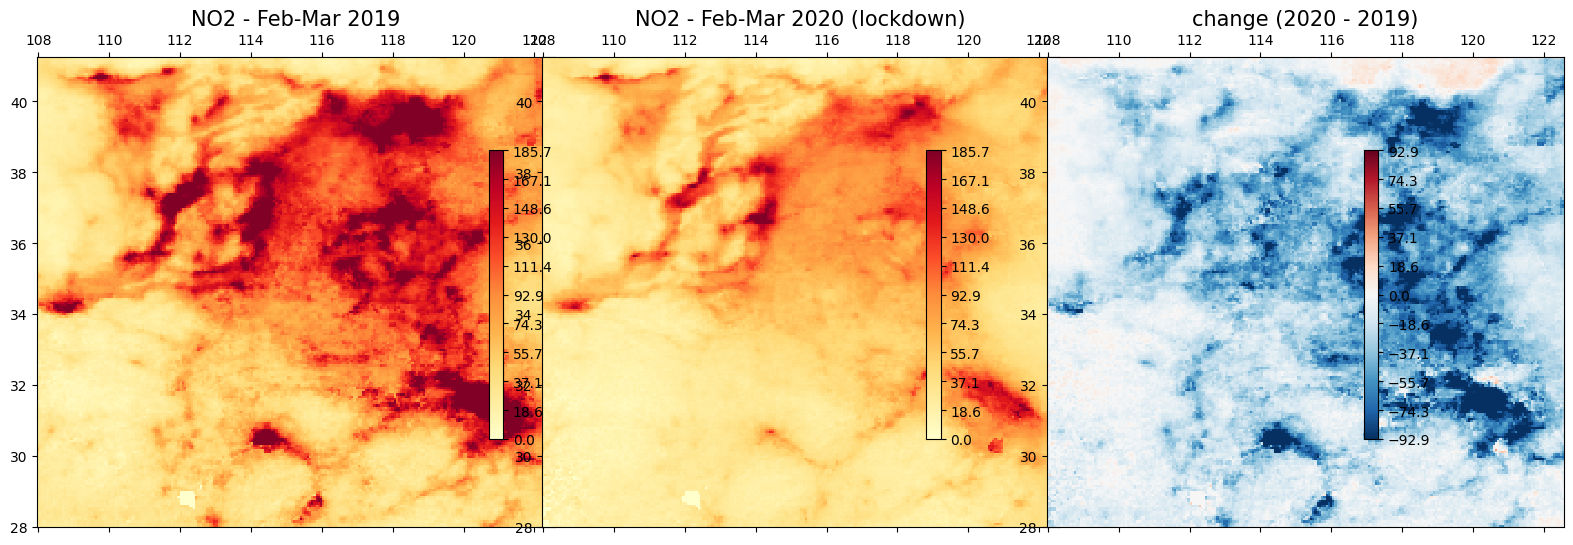

mean tropospheric NO2 fell 36% (Feb-Mar 2020 vs 2019)


In [2]:
# NO2 is a single-band tropospheric column; umol/m^2 for readable numbers, shared vmax across years.
if a2019 and a2020:
    u = 1e6; n19 = np.asarray(a2019.read_array(), dtype="float32"); n20 = np.asarray(a2020.read_array(), dtype="float32")
    n19 = (n19 if n19.ndim == 2 else n19[0]) * u; n20 = (n20 if n20.ndim == 2 else n20[0]) * u
    vmax = float(np.nanpercentile(np.concatenate([n19.ravel(), n20.ravel()]), 98))
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    plot_arr(n19, a2019, ax[0], cmap="YlOrRd", title="NO2 - Feb-Mar 2019", vmin=0, vmax=vmax)
    plot_arr(n20, a2020, ax[1], cmap="YlOrRd", title="NO2 - Feb-Mar 2020 (lockdown)", vmin=0, vmax=vmax)
    plot_arr(n20 - n19, a2019, ax[2], cmap="RdBu_r", title="change (2020 - 2019)", vmin=-vmax/2, vmax=vmax/2)
    plt.tight_layout(); plt.show()
    print(f"mean tropospheric NO2 fell {(1 - np.nanmean(n20)/np.nanmean(n19))*100:.0f}% (Feb-Mar 2020 vs 2019)")

## Monthly time series, 2019–2021

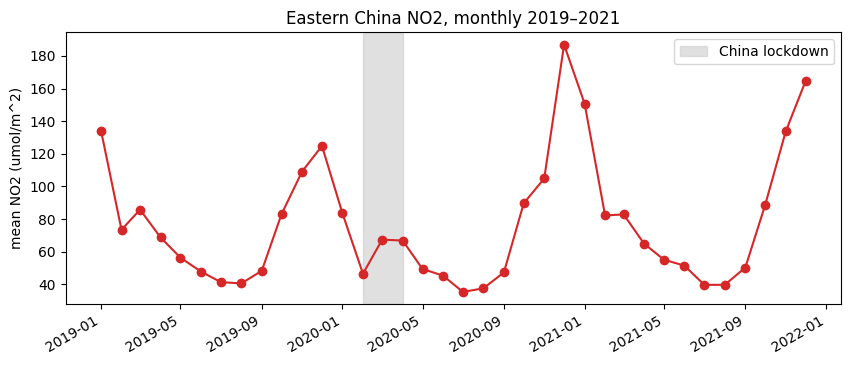

36 monthly composites


In [3]:
# Regional-mean NO2 per month; shade the main lockdown window. (matplotlib chart)
if a2019 and a2020:
    months, vals = [], []
    for y in (2019, 2020, 2021):
        for m in range(1, 13):
            s = date(y, m, 1); e = date(y + (m == 12), (m % 12) + 1, 1)
            p = EarthLens(data_source="gee", cadence="raw", dataset=C, variables=[NO2], aoi=AOI, start=s.isoformat(), end=e.isoformat(), scale=7000, reducer="mean").load()[0]
            if p:
                arr = np.asarray(p.read_array(), dtype="float32"); arr = arr if arr.ndim == 2 else arr[0]
                months.append(pd.Timestamp(s)); vals.append(np.nanmean(arr) * 1e6)
    fig, ax = plt.subplots(figsize=(10, 4)); ax.plot(months, vals, "-o", color="tab:red")
    ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-01"), color="0.8", alpha=0.6, label="China lockdown")
    ax.set(ylabel="mean NO2 (umol/m^2)", title="Eastern China NO2, monthly 2019–2021"); ax.legend(); fig.autofmt_xdate(); plt.show()
    print(f"{len(vals)} monthly composites")

## Recap

The NO₂ maps (including the derived difference) are rendered with `Dataset.plot()`; the monthly time series is a matplotlib chart.

## Try it yourself

- Re-point `AOI`, or compare other year pairs.
- See the [GEE backend reference](../../reference/gee/introduction.md).